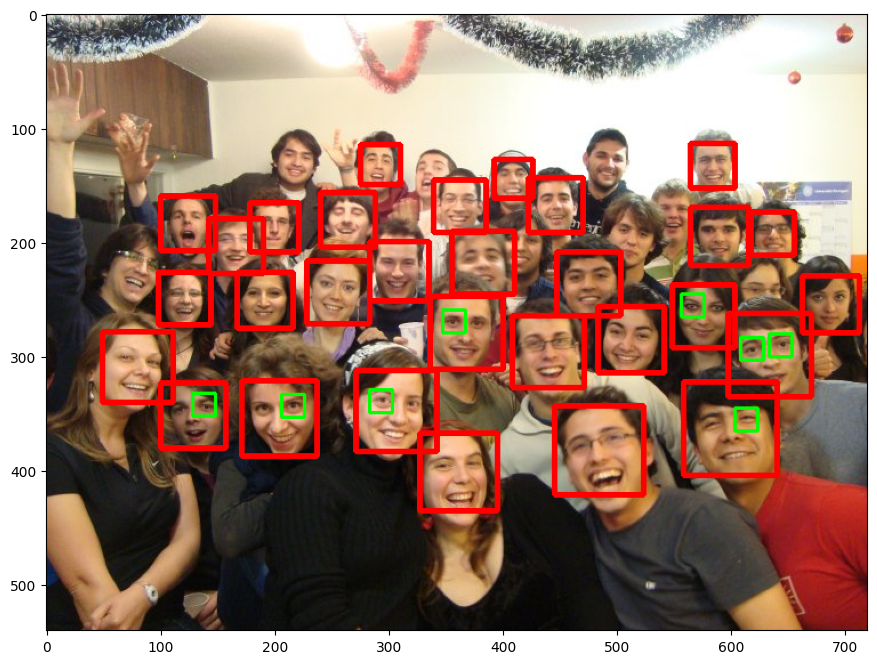

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Load BOTH XML files
# Make sure these files are in the 'data/haarcascades/' folder or use cv2.data.haarcascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Load image
objeto = cv2.imread('turma.jpg')

# Fix color for Matplotlib (OpenCV is BGR, Matplotlib is RGB)
objeto = cv2.cvtColor(objeto, cv2.COLOR_BGR2RGB)

def face_and_eye_detector(imagem):
    # Work on a copy to avoid modifying the original
    final_image = imagem.copy()
    
    # Convert to gray for detection
    gray_image = cv2.cvtColor(final_image, cv2.COLOR_RGB2GRAY)
    
    # 2. Detect Faces First
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.3, minNeighbors=5)
    
    if len(faces) == 0:
        return final_image # No faces found
    
    for (x, y, w, h) in faces:
        # Draw the Face Rectangle (Red)
        cv2.rectangle(final_image, (x, y), (x+w, y+h), (255, 0, 0), 3)
        
        # 3. Create ROI (Region of Interest)
        # We slice the image to look ONLY inside the current face
        roi_gray = gray_image[y:y+h, x:x+w]
        roi_color = final_image[y:y+h, x:x+w]
        
        # 4. Detect Eyes INSIDE the Face ROI
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.2, minNeighbors=3)
        
        for (ex, ey, ew, eh) in eyes:
            # Draw the Eye Rectangles (Green)
            # Note: We draw on 'roi_color', which is a reference to 'final_image'
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
            
    return final_image

# Run detection
resultado = face_and_eye_detector(objeto)

# Display
plt.figure(figsize=(12,8))
plt.imshow(resultado)
plt.show()